<a href="https://colab.research.google.com/github/sarahj150806-ctrl/Internship/blob/main/Sarah_J_(LD_1787379388295).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Placement Eligibility
Predict whether a student is likely to meet a placement eligibility criterion.

PROJECT ELEMENT	REQUIREMENT
Objective- Build a binary classification solution for the student placement eligibility use case.
Dataset	dataset_07_student_placement_eligibility.csv • 1,000 rows • 6 predictors + target
Target	target = 1 represents the positive/risk/event class; target = 0 represents the negative/non-event class.


Input variables	cgpa, attendance_pct, coding_score, projects_completed, internship_months, backlogs
Required algorithm	Logistic Regression. Establish a simple baseline where useful and compare only when technically justified.
Performance metrics	Accuracy, Precision, Recall, F1-score and ROC-AUC; include a confusion matrix.


In [28]:
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

These are all the packages and variables used in this program

In [29]:
df = pd.read_csv("dataset_07_student_placement_eligibility.csv")

Here, the data is being uploaded as a "CSV" file.
And the "pandas" package is being used to read the uploaded CSV file

In [30]:
print("Shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
print(df.head())

Shape: (1000, 7)

Column names:
['cgpa', 'attendance_pct', 'coding_score', 'projects_completed', 'internship_months', 'backlogs', 'target']

Data types:
cgpa                  float64
attendance_pct        float64
coding_score            int64
projects_completed      int64
internship_months       int64
backlogs                int64
target                  int64
dtype: object

First 5 rows:
   cgpa  attendance_pct  coding_score  projects_completed  internship_months  \
0  8.18           76.43             4                   3                 14   
1  9.28           46.50             3                   3                 50   
2  7.61           30.59             6                   2                 25   
3  7.47           50.98             0                   4                 56   
4  6.17           25.42             2                   2                 55   

   backlogs  target  
0         4       1  
1         5       0  
2         2       1  
3         3       0  
4         4      

"df.shape"- tells us the size of the dataset.
"df.columns"- shows the names of the columns.
"df.dtypes"- tells us what type of information each column contains.
"df.head()"- shows the first five rows of the dataset

In [31]:
print("Missing values:")
print(df.isnull())
print(df.isnull().sum())

Missing values:
      cgpa  attendance_pct  coding_score  projects_completed  \
0    False           False         False               False   
1    False           False         False               False   
2    False           False         False               False   
3    False           False         False               False   
4    False           False         False               False   
..     ...             ...           ...                 ...   
995  False           False         False               False   
996  False           False         False               False   
997  False           False         False               False   
998  False           False         False               False   
999  False           False         False               False   

     internship_months  backlogs  target  
0                False     False   False  
1                False     False   False  
2                False     False   False  
3                False     False   False  


In this cell, the dataset is checked for any missing values.
As displayed in the output, there are no missing values in the dataset

In [32]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In this cell, the dataset is checked for any duplicaye values. As displayed in the output, there are no duplicate records.

In [33]:
print(df['target'].value_counts())

target
1    500
0    500
Name: count, dtype: int64


The target variable contains 500 observations in class 0 and 500 observations in class 1. Therefore, the dataset is perfectly balanced, with each class representing 50% of the observations. This reduces the risk of the model being biased toward a majority class.

In [34]:
print(df.describe())

              cgpa  attendance_pct  coding_score  projects_completed  \
count  1000.000000     1000.000000   1000.000000         1000.000000   
mean      7.262610       50.859510      2.999000            2.976000   
std       1.255403       20.161735      1.711119            1.749424   
min       4.000000        0.000000      0.000000            0.000000   
25%       6.470000       37.447500      2.000000            2.000000   
50%       7.270000       50.595000      3.000000            3.000000   
75%       8.102500       64.027500      4.000000            4.000000   
max      10.000000      100.000000     10.000000            9.000000   

       internship_months     backlogs      target  
count        1000.000000  1000.000000  1000.00000  
mean           30.539000     2.988000     0.50000  
std            17.195935     1.722447     0.50025  
min             1.000000     0.000000     0.00000  
25%            16.000000     2.000000     0.00000  
50%            30.000000     3.000000  

It gives information such as:
count
mean
standard deviation
minimum
maximum
quartiles

In [35]:
for column in df.columns:
    print(
        column,
        "\nMin =", df[column].min(),
        "\nMax =", df[column].max()
    )

cgpa 
Min = 4.0 
Max = 10.0
attendance_pct 
Min = 0.0 
Max = 100.0
coding_score 
Min = 0 
Max = 10
projects_completed 
Min = 0 
Max = 9
internship_months 
Min = 1 
Max = 60
backlogs 
Min = 0 
Max = 9
target 
Min = 0 
Max = 1


This cell checks the minimum and maximum values of each variable.

In [36]:
X = df.drop(columns=['target'])
y = df['target']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 6)
y shape: (1000,)


Here we separate the predictor variables from the target variable. X contains the six student-related features used for prediction, while y contains the target that the model needs to predict.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


We divide the data into 80% training and 20% testing data. The training data is used to teach the model, while the testing data is kept unseen to evaluate its performance.

In [38]:
model = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logistic_regression',
                 LogisticRegression(max_iter=1000, random_state=42))])

The pipeline makes sure that the scaling is learned only from the training data, and then the same scaling is applied to the test data.

In [39]:
y_pred = model.predict(X_test)

# Probability of class 1
y_prob = model.predict_proba(X_test)[:, 1]

fit() means: “Learn from these examples.”
Here it trains the modle using the traget features and their traget values

In [40]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print("ROC-AUC  :", round(roc_auc, 4))

Accuracy : 0.7
Precision: 0.6887
Recall   : 0.73
F1-score : 0.7087
ROC-AUC  : 0.7874


The first line generates the predicted classes for the test data. The second line obtains the predicted probability of class 1, which is used for probability-based evaluation.

In [41]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67 33]
 [27 73]]


This cell evaluates the trained model using several performance measures.

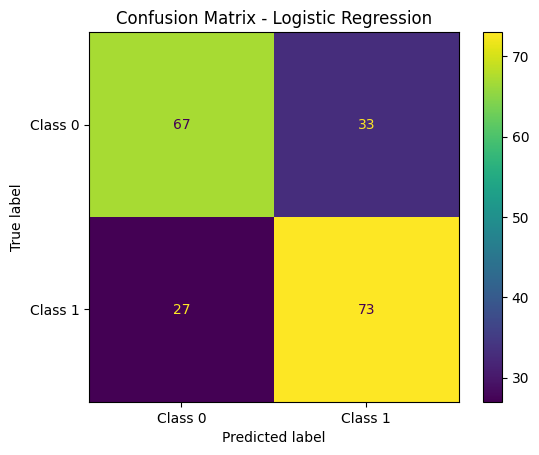

In [42]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Class 0', 'Class 1']
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

The confusion matrix shows exactly how the model's predictions compare with the actual classes.

In [43]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.71      0.67      0.69       100
           1       0.69      0.73      0.71       100

    accuracy                           0.70       200
   macro avg       0.70      0.70      0.70       200
weighted avg       0.70      0.70      0.70       200



This cell visualizes the confusion matrix so that the correct and incorrect predictions can be understood more easily.

In [44]:
logistic_model = model.named_steps['logistic_regression']

coefficients = logistic_model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefficients,
    'Odds_Ratio': np.exp(coefficients)
})

coef_df = coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

print(coef_df)

              Feature  Coefficient  Odds_Ratio
5            backlogs     0.618049    1.855305
1      attendance_pct     0.556093    1.743846
3  projects_completed     0.551368    1.735626
4   internship_months    -0.395385    0.673421
0                cgpa    -0.462246    0.629868
2        coding_score    -0.517072    0.596264


Here there are number of test samples for each target class, giving a detailed view of model performance.